#  Week 3: Statistics and Probability Analysis of the Titanic Dataset

## Analyst Lab Africa Data Science Internship

### Prepared by:
**Konya Lavanne Hope Chisira**

---

## Overview

This notebook explores the fundamental concepts of statistics and probability using the Titanic dataset. The analysis examines passenger characteristics through descriptive statistics, probability, sampling, confidence intervals, hypothesis testing, and correlation analysis.

The objective is to understand how statistical methods are applied to real-world data in order to identify patterns, quantify uncertainty, and support evidence-based conclusions.

#  Objectives

This analysis aims to:

- Examine the statistical characteristics of the Titanic dataset.
- Summarize numerical and categorical variables using descriptive statistics.
- Calculate measures of central tendency and dispersion.
- Apply probability concepts using passenger information.
- Examine probability distributions of numerical variables.
- Demonstrate sampling techniques.
- Estimate confidence intervals.
- Perform hypothesis testing.
- Investigate relationships between variables using correlation analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import t, skew, kurtosis

plt.style.use("ggplot")

%matplotlib inline

# Loading the Dataset

The Titanic dataset contains demographic and travel information for passengers aboard the RMS Titanic. It includes variables such as age, fare, passenger class, sex, family relationships, and survival status.

The dataset serves as an excellent example for demonstrating statistical techniques because it contains both numerical and categorical variables.

In [2]:
# Load dataset

df = pd.read_csv("Titanic-Dataset.csv")

# Display first five rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

Before conducting statistical analysis, it is important to understand the structure and quality of the dataset.

This section examines:

- Number of observations
- Number of variables
- Data types
- Missing values
- Overall dataset structure

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 891
Columns: 12
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Descriptive Statistics

Descriptive statistics summarize the numerical characteristics of the dataset and provide an overview of the distribution of each variable.

The statistics presented include:

- Count
- Mean
- Standard deviation
- Minimum
- Quartiles
- Maximum

These measures provide a foundation for subsequent statistical analysis.

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Descriptive Statistics for Categorical Variables

Categorical variables are summarized by examining:

- Number of observations
- Number of unique categories
- Most frequent category
- Frequency of occurrence

These summaries provide an overview of the passenger characteristics represented in the dataset.

In [5]:
df.describe(include="object")

C:\Users\konya\AppData\Local\Temp\ipykernel_23684\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


# Measures of Central Tendency

Measures of central tendency identify the central value around which observations are distributed.

The three commonly used measures are:

- Mean
- Median
- Mode

Each measure contributes to understanding the typical characteristics of passengers within the dataset.

In [6]:
numeric_columns = df.select_dtypes(include=np.number)

numeric_columns.mean()

PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.699118
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

In [7]:
numeric_columns.median()

PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64

In [8]:
df.mode().iloc[0]

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object

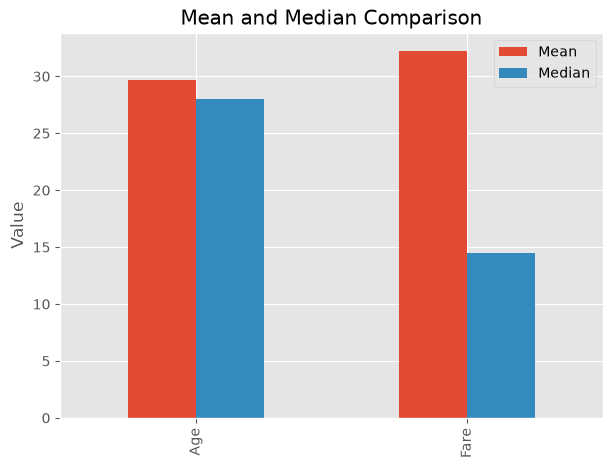

In [9]:
comparison = pd.DataFrame({
    "Mean":[df["Age"].mean(), df["Fare"].mean()],
    "Median":[df["Age"].median(), df["Fare"].median()]
}, index=["Age","Fare"])

comparison.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Mean and Median Comparison")
plt.ylabel("Value")

plt.show()

The comparison between the mean and median provides insight into the symmetry of the numerical variables.

For both **Age** and **Fare**, noticeable differences between the mean and median suggest that the distributions are influenced by extreme values. In particular, the fare distribution is expected to exhibit positive skewness due to a relatively small number of passengers paying substantially higher ticket prices.

#  Measures of Dispersion

While measures of central tendency describe the centre of the data, measures of dispersion explain how observations are spread around that centre.

Understanding variability is essential because two variables may have similar averages but completely different distributions.

This section examines the following measures of dispersion:

- Range
- Variance
- Standard Deviation
- Interquartile Range (IQR)

Together, these statistics provide a clearer understanding of passenger age and ticket fare variability.

## Range

The **range** represents the difference between the largest and smallest observations.

It provides a simple measure of variability and indicates the overall spread of the data.

Although easy to calculate, the range is sensitive to extreme values.

In [10]:
# Calculate the range

range_values = numeric_columns.max() - numeric_columns.min()

range_values

PassengerId    890.0000
Survived         1.0000
Pclass           2.0000
Age             79.5800
SibSp            8.0000
Parch            6.0000
Fare           512.3292
dtype: float64

## Variance

Variance measures the average squared distance of observations from the mean.

Higher variance indicates greater variability within the data, while lower variance suggests that observations are clustered more closely around the average.

Since variance is expressed in squared units, it is primarily useful for statistical calculations rather than direct interpretation.

In [11]:
numeric_columns.var()

PassengerId    66231.000000
Survived           0.236772
Pclass             0.699015
Age              211.019125
SibSp              1.216043
Parch              0.649728
Fare            2469.436846
dtype: float64

## Standard Deviation

Standard deviation measures the average amount by which observations differ from the mean.

Unlike variance, standard deviation is expressed in the original units of measurement, making interpretation more intuitive.

Variables with larger standard deviations exhibit greater variability.

In [12]:
numeric_columns.std()

PassengerId    257.353842
Survived         0.486592
Pclass           0.836071
Age             14.526497
SibSp            1.102743
Parch            0.806057
Fare            49.693429
dtype: float64

## Interquartile Range (IQR)

The Interquartile Range (IQR) measures the spread of the middle 50% of observations.

It is calculated as:

\[
IQR = Q3 - Q1
\]

Because the IQR ignores extreme observations, it provides a robust measure of variability and is particularly useful when distributions contain outliers.

In [13]:
Q1 = numeric_columns.quantile(0.25)

Q3 = numeric_columns.quantile(0.75)

IQR = Q3 - Q1

IQR

PassengerId    445.0000
Survived         1.0000
Pclass           1.0000
Age             17.8750
SibSp            1.0000
Parch            0.0000
Fare            23.0896
dtype: float64

# Distribution of Passenger Age

The histogram illustrates how passenger ages are distributed across the Titanic dataset.

Understanding this distribution helps identify the age groups that are most represented and reveals whether the data are approximately symmetric or skewed.

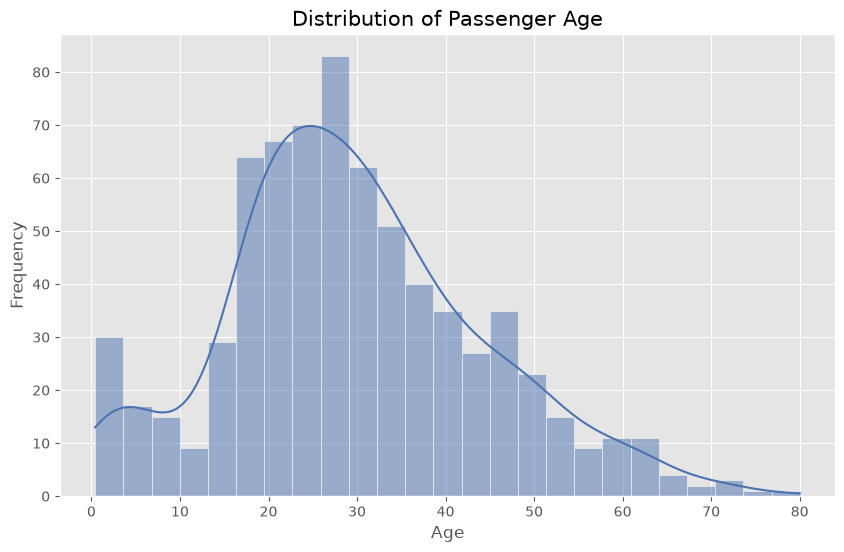

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Age",
    bins=25,
    kde=True,
    color="#4C72B0"
)

plt.title("Distribution of Passenger Age", fontsize=15)

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

### 💡 Interpretation

The histogram shows that passenger ages are concentrated within the young adult age group, while relatively few passengers belong to the elderly age category.

The smooth density curve indicates that the distribution is not perfectly symmetric, suggesting that the age variable may exhibit moderate skewness. This observation motivates the formal skewness analysis performed later in the notebook.

# Distribution of Passenger Fare

Ticket fares vary considerably across passengers because different travel classes charge different prices.

The violin plot illustrates both the distribution and the density of ticket fares, making it easier to identify where observations are concentrated.

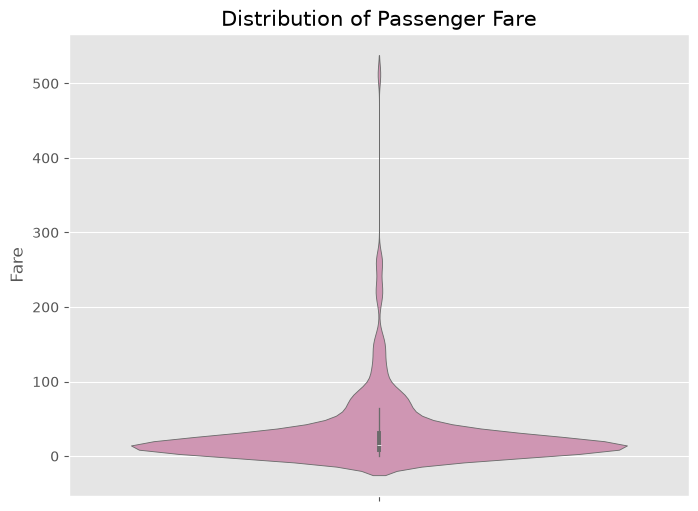

In [15]:
plt.figure(figsize=(8,6))

sns.violinplot(
    y=df["Fare"],
    color="#D98CB3"
)

plt.title("Distribution of Passenger Fare", fontsize=15)

plt.ylabel("Fare")

plt.show()

### 💡 Interpretation

The violin plot indicates that most passengers pay relatively low fares, while comparatively few passengers pay premium ticket prices.

The wider lower section of the violin reflects a high concentration of lower fares, whereas the long upper tail suggests the presence of expensive tickets purchased by a smaller group of passengers. This pattern is consistent with a positively skewed distribution.

# Key Observations

The measures of dispersion reveal substantial variability among the numerical variables within the Titanic dataset.

Passenger age exhibits moderate variability, reflecting the presence of children, adults, and elderly passengers.

Ticket fare demonstrates considerably greater variability due to differences in travel class and accommodation. The distribution contains several high-value observations that increase both the range and the standard deviation.

Together, these measures complement the measures of central tendency by providing a more complete understanding of how passenger characteristics are distributed.

#  Probability Concepts

Probability measures the likelihood that an event will occur. It is expressed as a value between **0 and 1**, where:

- **0** represents an impossible event.
- **1** represents a certain event.

Probability enables analysts to quantify uncertainty and make evidence-based predictions from observed data.

The probability of an event is calculated as:

\[
P(A)=\frac{\text{Number of Favourable Outcomes}}{\text{Total Number of Outcomes}}
\]

The Titanic dataset provides an excellent opportunity to demonstrate probability using real passenger characteristics such as survival status, gender, and passenger class.

## Probability of Passenger Survival

The first probability calculated in this analysis is the likelihood that a randomly selected passenger survives the Titanic disaster.

This probability provides an overall measure of survival within the dataset.

In [16]:
# Probability of survival

survived = len(df[df["Survived"] == 1])

total_passengers = len(df)

prob_survival = survived / total_passengers

print(f"Probability of Survival: {prob_survival:.3f}")

Probability of Survival: 0.384


## Probability of Selecting a Female Passenger

This example estimates the probability that a randomly selected passenger is female.

Understanding the gender distribution provides additional context for later analyses involving survival.

In [17]:
female = len(df[df["Sex"] == "female"])

prob_female = female / total_passengers

print(f"Probability of Selecting a Female Passenger: {prob_female:.3f}")

Probability of Selecting a Female Passenger: 0.352


## Probability of Selecting a First-Class Passenger

Passenger class represents the level of accommodation purchased before boarding the ship.

This example estimates the probability that a randomly selected passenger travelled in First Class.

In [18]:
first_class = len(df[df["Pclass"] == 1])

prob_first = first_class / total_passengers

print(f"Probability of Selecting a First-Class Passenger: {prob_first:.3f}")

Probability of Selecting a First-Class Passenger: 0.242


## Probability of Selecting a Passenger Younger than 18 Years

Age plays an important role in understanding the demographic composition of the passengers.

The following calculation estimates the probability that a randomly selected passenger is below eighteen years of age.

In [19]:
children = len(df[df["Age"] < 18])

prob_children = children / total_passengers

print(f"Probability of Selecting a Passenger Below 18 Years: {prob_children:.3f}")

Probability of Selecting a Passenger Below 18 Years: 0.127


#  Comparison of Event Probabilities

The following chart compares the probabilities of four passenger characteristics:

- Passenger survives
- Passenger is female
- Passenger travels in First Class
- Passenger is below 18 years of age

Presenting these probabilities together provides a clear comparison of how common each event is within the dataset.

C:\Users\konya\AppData\Local\Temp\ipykernel_23684\737939915.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


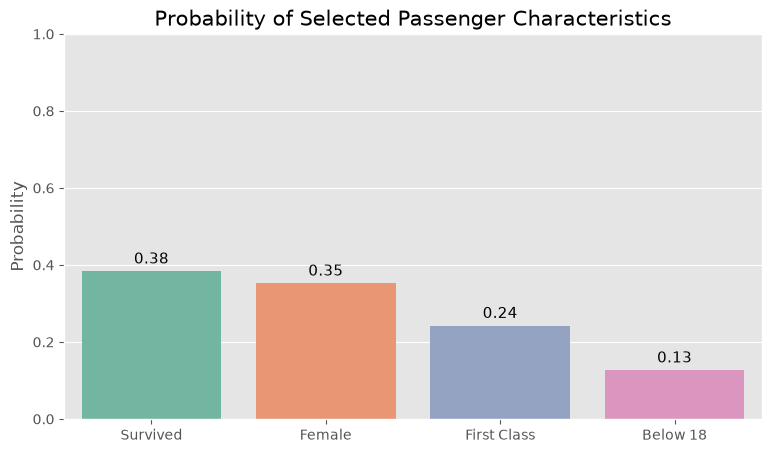

In [20]:
events = [
    "Survived",
    "Female",
    "First Class",
    "Below 18"
]

probabilities = [
    prob_survival,
    prob_female,
    prob_first,
    prob_children
]

plt.figure(figsize=(9,5))

bars = sns.barplot(
    x=events,
    y=probabilities,
    palette="Set2"
)

plt.ylim(0,1)

plt.ylabel("Probability")

plt.title("Probability of Selected Passenger Characteristics", fontsize=15)

# Add probability labels
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        fontsize=11
    )

plt.show()

## Interpretation

The probability analysis provides a concise overview of the composition of the Titanic dataset.

The calculated probabilities indicate that survival is less common than non-survival, reflecting the tragic outcome of the disaster. The dataset also contains a greater proportion of male passengers than female passengers, while First-Class travellers represent a smaller share of the total passenger population.

Similarly, passengers below eighteen years of age constitute only a limited proportion of those aboard the Titanic. These probability estimates establish a statistical foundation for subsequent analyses involving confidence intervals and hypothesis testing.

#  Conditional Probability

Conditional probability measures the likelihood of an event occurring given that another event has already occurred.



In this analysis, conditional probability helps determine how survival changes when additional passenger characteristics are considered.

In [21]:
female_passengers = df[df["Sex"] == "female"]

prob_survival_female = (
    female_passengers["Survived"].sum()
    / len(female_passengers)
)

print(
    f"Probability of Survival Given Female: {prob_survival_female:.3f}"
)

Probability of Survival Given Female: 0.742


In [22]:
first_class_passengers = df[df["Pclass"] == 1]

prob_survival_first = (
    first_class_passengers["Survived"].sum()
    / len(first_class_passengers)
)

print(
    f"Probability of Survival Given First Class: {prob_survival_first:.3f}"
)

Probability of Survival Given First Class: 0.630


C:\Users\konya\AppData\Local\Temp\ipykernel_23684\3452916689.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


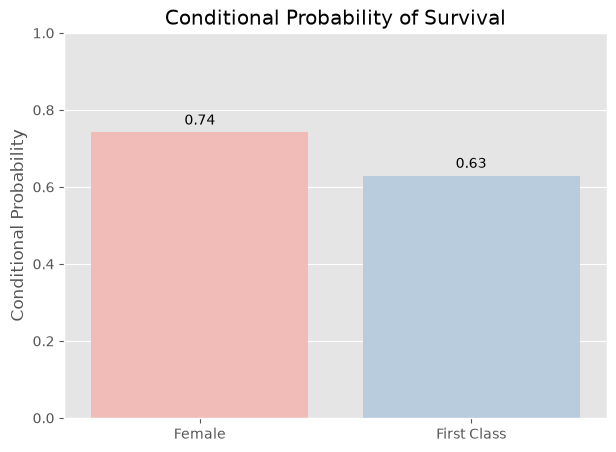

In [23]:
plt.figure(figsize=(7,5))

categories = [
    "Female",
    "First Class"
]

values = [
    prob_survival_female,
    prob_survival_first
]

bars = sns.barplot(
    x=categories,
    y=values,
    palette="Pastel1"
)

plt.ylim(0,1)

plt.ylabel("Conditional Probability")

plt.title("Conditional Probability of Survival")

for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.02,
        f"{height:.2f}",
        ha="center"
    )

plt.show()

## Interpretation

The conditional probabilities demonstrate that survival is influenced by passenger characteristics rather than occurring randomly.

Female passengers and First-Class passengers exhibit higher survival probabilities than the overall passenger population. This observation highlights the importance of considering multiple variables when analysing real-world events and illustrates how conditional probability provides deeper insights than simple probability alone.

#  Probability Distributions

A probability distribution describes how the values of a random variable are distributed.

Understanding the shape of a distribution is important because many statistical methods assume that data follow a particular distribution. Examining the distribution helps identify symmetry, skewness, and the presence of extreme observations.

This section analyses the distribution of passenger age and ticket fare using statistical measures and graphical techniques.

## Distribution of Passenger Age

Passenger age is one of the most informative numerical variables in the Titanic dataset. Examining its distribution provides insight into the age composition of the passengers and helps determine whether the variable follows an approximately normal distribution.

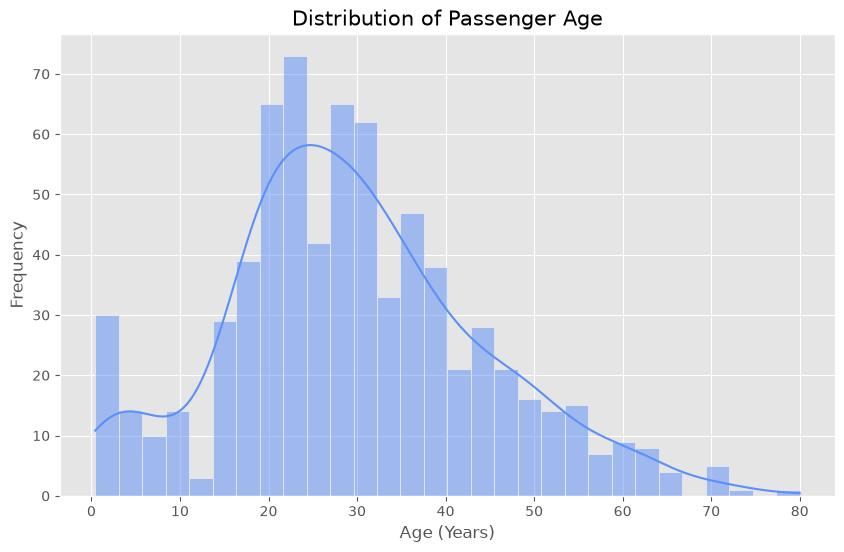

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Age",
    kde=True,
    bins=30,
    color="#5B8FF9"
)

plt.title("Distribution of Passenger Age", fontsize=15)
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")

plt.show()

#  Skewness

Skewness measures the degree of asymmetry within a distribution.

A distribution may be:

- Symmetric (Skewness ≈ 0)
- Positively Skewed (Right-skewed)
- Negatively Skewed (Left-skewed)

Calculating skewness provides a quantitative assessment of the distribution's shape.

In [25]:
age_skew = skew(df["Age"].dropna())

fare_skew = skew(df["Fare"])

print(f"Age Skewness : {age_skew:.3f}")
print(f"Fare Skewness: {fare_skew:.3f}")

Age Skewness : 0.388
Fare Skewness: 4.779


## Density Curves

Kernel Density Estimation (KDE) provides a smooth representation of the distribution of a numerical variable.

Comparing density curves allows differences in distribution shape and variability to be observed more clearly.

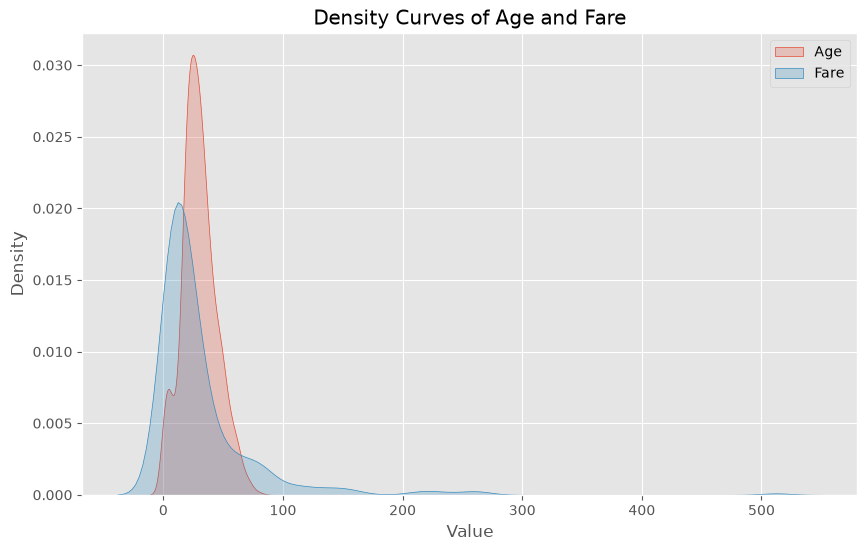

In [26]:
plt.figure(figsize=(10,6))

sns.kdeplot(df["Age"].dropna(), label="Age", fill=True)

sns.kdeplot(df["Fare"], label="Fare", fill=True)

plt.title("Density Curves of Age and Fare")

plt.xlabel("Value")

plt.legend()

plt.show()

#  Kurtosis

Kurtosis measures the concentration of observations within the tails of a distribution.

Higher kurtosis indicates heavier tails and a greater likelihood of extreme observations, while lower kurtosis suggests lighter tails.

Evaluating kurtosis complements skewness by providing additional information about the overall distribution.

In [27]:
age_kurt = kurtosis(df["Age"].dropna())

fare_kurt = kurtosis(df["Fare"])

print(f"Age Kurtosis : {age_kurt:.3f}")
print(f"Fare Kurtosis: {fare_kurt:.3f}")

Age Kurtosis : 0.169
Fare Kurtosis: 33.204


# Quantile-Quantile (Q-Q) Plot

A Q-Q plot compares the observed data with a theoretical normal distribution.

When the points closely follow the reference line, the variable is considered approximately normally distributed.

Systematic deviations from the line indicate departures from normality.

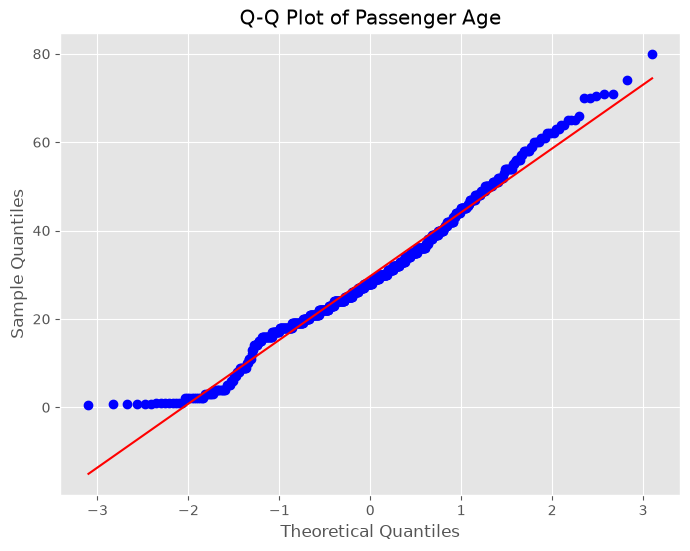

In [28]:
plt.figure(figsize=(8,6))

stats.probplot(
    df["Age"].dropna(),
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Passenger Age")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

plt.show()

## Interpretation

The probability distribution analysis indicates that passenger age exhibits moderate variation, while ticket fare displays a stronger positive skew due to a relatively small number of passengers purchasing high-value tickets.

The skewness and kurtosis statistics support the graphical observations by quantifying the asymmetry and tail behaviour of each distribution.

The Q-Q plot provides additional evidence regarding the normality of passenger age and helps determine whether statistical techniques that assume normality are appropriate for subsequent analyses.

#  Sampling

Sampling involves selecting a subset of observations from a larger population to draw conclusions about that population.

Rather than analysing every observation repeatedly, statistical inference relies on representative samples to estimate population characteristics efficiently.

This section demonstrates Simple Random Sampling using the Titanic dataset.

In [29]:
sample_df = df.sample(
    n=150,
    random_state=42
)

sample_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


In [30]:
comparison = pd.DataFrame({
    "Population Mean": numeric_columns.mean(),
    "Sample Mean": sample_df.select_dtypes(include=np.number).mean()
})

comparison

,Population Mean,Sample Mean
PassengerId,446.000000,444.560000
Survived,0.383838,0.406667
Pclass,2.308642,2.186667
Age,29.699118,31.067177
SibSp,0.523008,0.426667
Parch,0.381594,0.386667
Fare,32.204208,32.372389


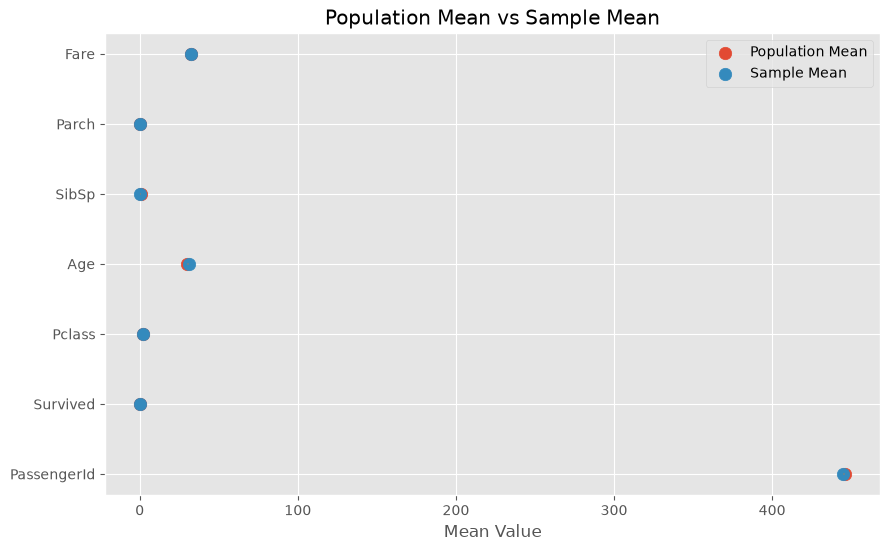

In [31]:
comparison_plot = comparison.reset_index().rename(columns={"index": "Variable"})

plt.figure(figsize=(10,6))

y = np.arange(len(comparison_plot))

plt.hlines(
    y,
    comparison_plot["Population Mean"],
    comparison_plot["Sample Mean"],
    color="gray",
    alpha=0.6
)

plt.scatter(
    comparison_plot["Population Mean"],
    y,
    label="Population Mean",
    s=80
)

plt.scatter(
    comparison_plot["Sample Mean"],
    y,
    label="Sample Mean",
    s=80
)

plt.yticks(y, comparison_plot["Variable"])

plt.xlabel("Mean Value")

plt.title("Population Mean vs Sample Mean")

plt.legend()

plt.show()

## Interpretation

The comparison demonstrates that the sample means closely approximate the population means across the numerical variables.

This similarity indicates that the randomly selected sample provides a reasonable representation of the overall dataset, supporting its suitability for inferential statistical analysis.

#  Confidence Intervals

A confidence interval estimates a range of values within which the true population parameter is expected to lie.

Unlike a single point estimate, a confidence interval acknowledges sampling uncertainty and provides a measure of estimation precision.

This analysis estimates the **95% confidence interval for the mean passenger age**.

In [32]:
# Remove missing age values

age = df["Age"].dropna()

# Sample statistics

n = len(age)
mean_age = age.mean()
std_age = age.std()

# Standard Error

se = std_age / np.sqrt(n)

# Margin of Error

margin = t.ppf(
    0.975,
    df=n-1
) * se

# Confidence Interval

lower = mean_age - margin
upper = mean_age + margin

print(f"Mean Age: {mean_age:.2f} years")
print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

Mean Age: 29.70 years
95% Confidence Interval: (28.63, 30.77)


## Confidence Interval for Passenger Age

The figure below illustrates the estimated mean passenger age together with its 95% confidence interval.

The central point represents the sample mean, while the vertical error bar represents the margin of error.

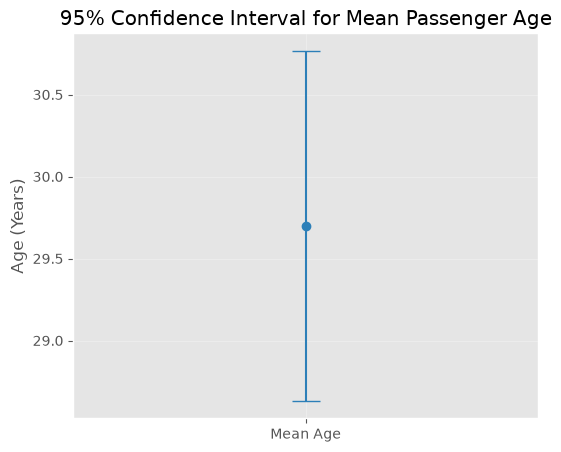

In [33]:
plt.figure(figsize=(6,5))

plt.errorbar(
    x=1,
    y=mean_age,
    yerr=margin,
    fmt='o',
    capsize=10,
    color="#2C7FB8"
)

plt.xticks([1], ["Mean Age"])

plt.ylabel("Age (Years)")

plt.title("95% Confidence Interval for Mean Passenger Age")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The confidence interval estimates the range within which the true average passenger age is expected to fall with 95% confidence.

A relatively narrow interval suggests that the estimate is precise, while a wider interval indicates greater sampling uncertainty.

#  Hypothesis Testing

Hypothesis testing evaluates whether observed differences between groups are statistically significant or simply the result of random variation.

This analysis investigates whether the average ticket fare differs significantly between passengers who survive and those who do not survive.

The hypotheses are:

**Null Hypothesis (H₀):**
There is no significant difference in the average fare paid by survivors and non-survivors.

**Alternative Hypothesis (H₁):**
There is a significant difference in the average fare paid by survivors and non-survivors.

In [34]:
# Separate the two groups

survivors = df[df["Survived"] == 1]["Fare"]

non_survivors = df[df["Survived"] == 0]["Fare"]

# Welch's t-test

t_stat, p_value = stats.ttest_ind(
    survivors,
    non_survivors,
    equal_var=False
)

print("T-statistic:", round(t_stat,3))
print("P-value:", round(p_value,5))

T-statistic: 6.839
P-value: 0.0


## Distribution of Ticket Fares by Survival Status

The violin plot compares the distribution of ticket fares between passengers who survive and those who do not survive.

It illustrates differences in the spread, density, and concentration of fares for each group.

C:\Users\konya\AppData\Local\Temp\ipykernel_23684\699153948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


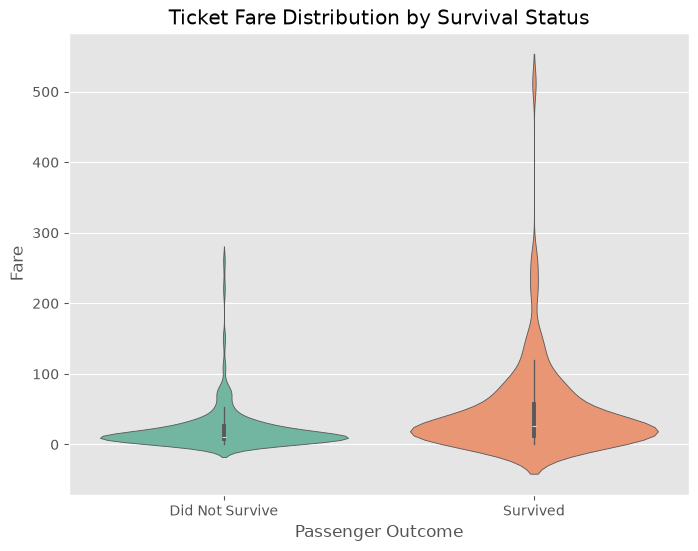

In [35]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x="Survived",
    y="Fare",
    palette="Set2"
)

plt.xticks(
    [0,1],
    ["Did Not Survive","Survived"]
)

plt.title("Ticket Fare Distribution by Survival Status")

plt.xlabel("Passenger Outcome")

plt.ylabel("Fare")

plt.show()

### Interpretation

The hypothesis test determines whether differences in average ticket fares between survivors and non-survivors are statistically significant.

If the p-value is less than **0.05**, the null hypothesis is rejected, indicating that ticket fare is significantly associated with survival.

If the p-value is greater than or equal to **0.05**, there is insufficient statistical evidence to conclude that ticket fare differs between the two groups.

# 🔗 Correlation Analysis

Correlation analysis measures the strength and direction of the linear relationship between numerical variables.

The Pearson correlation coefficient ranges from **−1** to **+1**, where values closer to the extremes indicate stronger relationships.

This analysis identifies the numerical variables most closely associated with passenger survival and other passenger characteristics.

In [36]:
correlation_matrix = numeric_columns.corr()

correlation_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## Correlation Heatmap

The heatmap provides a visual summary of the relationships among numerical variables.

It highlights both positive and negative correlations, making it easier to identify variables that may influence passenger survival.

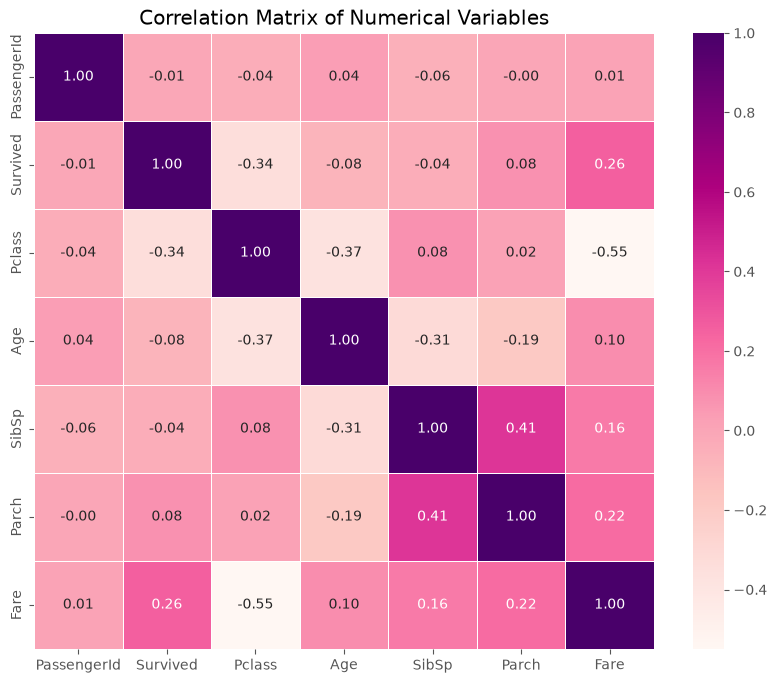

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdPu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

#  Pairwise Relationships Among Key Variables

While the correlation matrix provides numerical measures of association, a pair plot offers a visual representation of the relationships between multiple variables simultaneously.

This visualization examines the interactions among the most important numerical variables in the Titanic dataset:

- Passenger Age
- Ticket Fare
- Passenger Class
- Survival Status

The pair plot helps identify trends, clusters, and potential relationships that may not be immediately apparent from summary statistics alone.

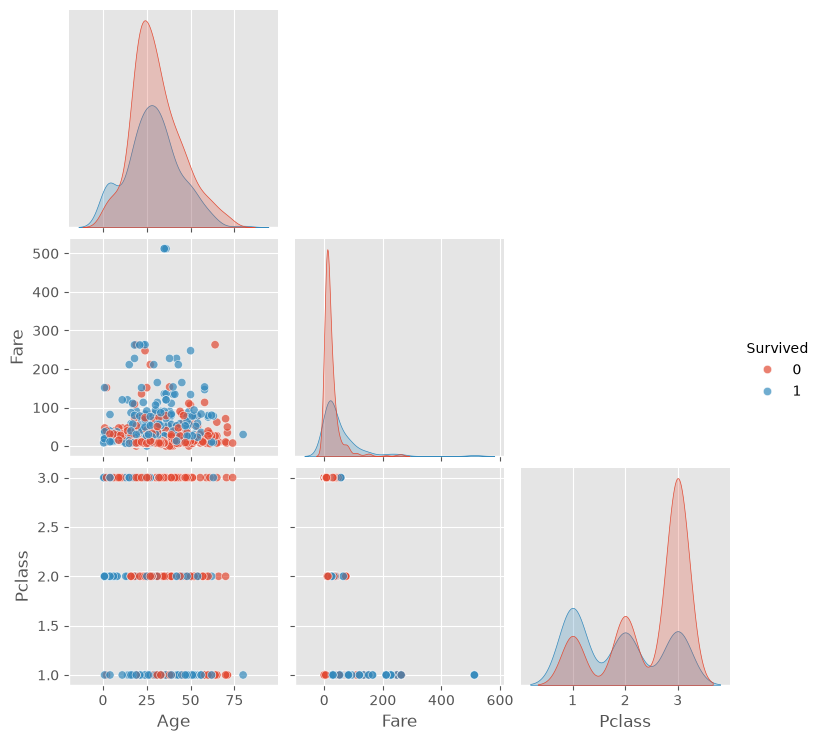

In [40]:
# Select key numerical variables

pairplot_data = df[["Age", "Fare", "Pclass", "Survived"]].dropna()

# Create pair plot

sns.pairplot(
    pairplot_data,
    hue="Survived",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha":0.7}
)

plt.show()

### Interpretation

The pair plot provides a comprehensive visual summary of the relationships among passenger age, ticket fare, passenger class, and survival status.

Several patterns become evident. Passengers travelling in higher classes generally pay higher fares, while survival appears more frequent among those who purchase higher-priced tickets. Age displays greater variability across the passenger population, although no strong linear relationship with fare is observed.

The pair plot complements the correlation analysis by revealing distribution patterns and group differences that are difficult to capture using numerical correlation coefficients alone.

In [38]:
survival_corr = (
    correlation_matrix["Survived"]
    .drop("Survived")
    .sort_values(ascending=False)
)

survival_corr

Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

C:\Users\konya\AppData\Local\Temp\ipykernel_23684\139950151.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


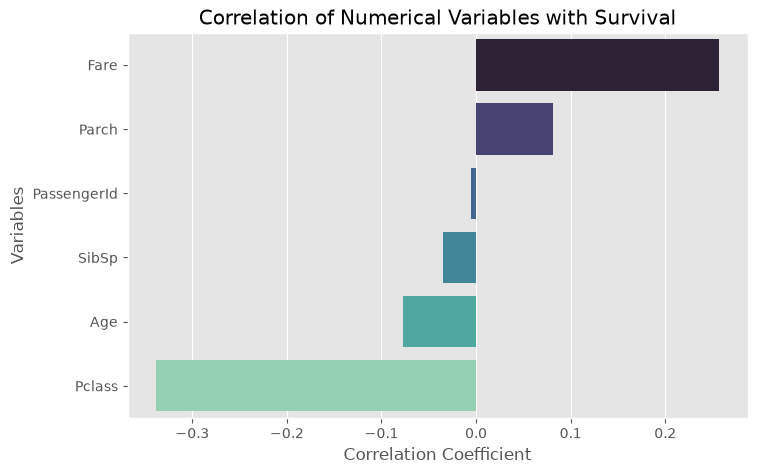

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=survival_corr.values,
    y=survival_corr.index,
    palette="mako"
)

plt.title("Correlation of Numerical Variables with Survival")

plt.xlabel("Correlation Coefficient")

plt.ylabel("Variables")

plt.show()

### Interpretation

The correlation analysis identifies the numerical variables that exhibit the strongest linear relationships with passenger survival.

Variables with higher positive coefficients are associated with an increased likelihood of survival, while negative coefficients indicate an inverse relationship. Although correlation does not establish causation, it provides valuable insight into potential predictors of survival and supports future predictive modelling.

#  Summary

This notebook applies statistical and probability concepts to the Titanic dataset in order to examine passenger characteristics and survival patterns.

The analysis includes descriptive statistics, measures of central tendency and dispersion, probability, probability distributions, sampling, confidence intervals, hypothesis testing, and correlation analysis.

The results demonstrate how statistical methods transform raw passenger data into meaningful insights that support objective interpretation and informed decision-making.

#  Key Takeaways

- Descriptive statistics summarize the characteristics of the Titanic dataset.
- Measures of central tendency and dispersion describe the centre and variability of passenger attributes.
- Probability and conditional probability quantify the likelihood of passenger characteristics and survival outcomes.
- Probability distributions reveal the shape and behaviour of numerical variables.
- Sampling demonstrates how representative subsets support statistical inference.
- Confidence intervals estimate population parameters while accounting for sampling uncertainty.
- Hypothesis testing evaluates whether observed differences are statistically significant.
- Correlation analysis identifies numerical variables most strongly associated with passenger survival.

#  Conclusion

This notebook demonstrates the practical application of statistical and probability techniques using the Titanic dataset.

The analyses provide a comprehensive understanding of passenger demographics, travel characteristics, and survival outcomes. By combining descriptive and inferential statistical methods, the notebook illustrates how data-driven evidence supports reliable conclusions and establishes a strong foundation for subsequent machine learning analyses.

# 📚 References

1. Analyst Lab Africa Data Science Internship Handbook.
2. Pandas Documentation. https://pandas.pydata.org/
3. NumPy Documentation. https://numpy.org/
4. Matplotlib Documentation. https://matplotlib.org/
5. Seaborn Documentation. https://seaborn.pydata.org/
6. SciPy Documentation. https://docs.scipy.org/